# Tweeeter Profiling

## 📥 1. Data Loading

Load tweets data from SQLite database:

1. **Connect to database**: Read all tables from `tweetsDB.sqlite`
2. **Date formatting**: Convert date columns to standardized `YYYY-MM-DD HH-MM-SS` format
   - `Timestamp`: tweet timestamp

In [4]:
import sqlite3
import pandas as pd
from datetime import datetime
from tabulate import tabulate

DB_PATH = "../data/tweetsCleanedDB.sqlite"
TABLE_NAME = "tweets"

conn = sqlite3.connect(DB_PATH)

print(f"Processing table: {TABLE_NAME}")

cols = pd.read_sql_query(f"PRAGMA table_info({TABLE_NAME});", conn)["name"].tolist()

df = pd.read_sql(f"SELECT * FROM {TABLE_NAME}", conn)
print(f"Loaded {len(df)} rows")

if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df['date'] = df['Timestamp'].dt.date
    df['time'] = df['Timestamp'].dt.time
    df['day_of_week'] = df['Timestamp'].dt.day_name()
    df['hour'] = df['Timestamp'].dt.hour
    df['year'] = df['Timestamp'].dt.year

print(f"\n{'='*50}")
print(f"Columns: {df.columns.tolist()}")
summary = pd.DataFrame([(TABLE_NAME, len(df))], columns=["table_name", "num_rows"])
print(tabulate(summary, headers="keys", tablefmt="github", showindex=False))

# Column datatypes
print(f"\n{'='*50}")
print("Column Datatypes:")
dtype_df = pd.DataFrame({
    "column": df.dtypes.index,
    "pandas_dtype": df.dtypes.values.astype(str),
    "sqlite_dtype": pd.read_sql_query(f"PRAGMA table_info({TABLE_NAME});", conn)["type"].tolist() + ["derived"] * (len(df.columns) - len(cols))
})
print(tabulate(dtype_df, headers="keys", tablefmt="github", showindex=False))

Processing table: tweets
Loaded 9909 rows

Columns: ['tweet_id', 'username', 'text', 'retweets', 'likes', 'timestamp', 'date', 'time', 'hour', 'day_name', 'year_week', 'year_month', 'year']
| table_name   |   num_rows |
|--------------|------------|
| tweets       |       9909 |

Column Datatypes:
| column     | pandas_dtype   | sqlite_dtype   |
|------------|----------------|----------------|
| tweet_id   | object         | TEXT           |
| username   | object         | TEXT           |
| text       | object         | TEXT           |
| retweets   | int64          | INTEGER        |
| likes      | int64          | INTEGER        |
| timestamp  | object         | TIMESTAMP      |
| date       | object         | DATE           |
| time       | object         | TEXT           |
| hour       | int64          | INTEGER        |
| day_name   | object         | TEXT           |
| year_week  | object         | TEXT           |
| year_month | object         | TEXT           |
| year       | 

## 🛠️ 2. Feature Engineering
1. **tweets:** tweet count per user (activity level)
2. **likes:**: likes per user (popularity or engagement)
3. **retweets**: retweets per user (influence and reach)

In [ ]:
user_agg = (
    df.groupby('username')
    .agg(
        tweet_count = ('text',     'count'),
        likes_total = ('likes',    'sum'),
        retweets_total = ('retweets', 'sum'),
    )
    .round(2)
    .sort_values('tweet_count', ascending=False)
    .reset_index()
)

print(f"Total unique users: {len(user_agg)}")
print(tabulate(user_agg.head(10), headers='keys', tablefmt='github', showindex=False))

Total unique users: 9365
| username        |   tweet_count |   likes_total |   retweets_total |
|-----------------|---------------|---------------|------------------|
| pjohnson        |             6 |           351 |              362 |
| nbrown          |             5 |           203 |              267 |
| awilliams       |             5 |           225 |              306 |
| amiller         |             4 |           271 |              253 |
| vbrown          |             4 |           108 |              213 |
| rjohnson        |             4 |           216 |              156 |
| nwhite          |             4 |           230 |              199 |
| wmitchell       |             4 |           123 |              269 |
| jessicawilliams |             4 |           216 |              251 |
| fsmith          |             4 |           170 |              301 |


### 🧩 3. K-Means++ Clustering on Author Behaviour Metrics
Run K-Means++ clustering for k = 2 to k = 11 on selected author-level metrics. For each k, record:

Within-Cluster Sum of Squares (WCSS) — inertia — for the Elbow Method
Silhouette Score — measures how well-separated the clusters are

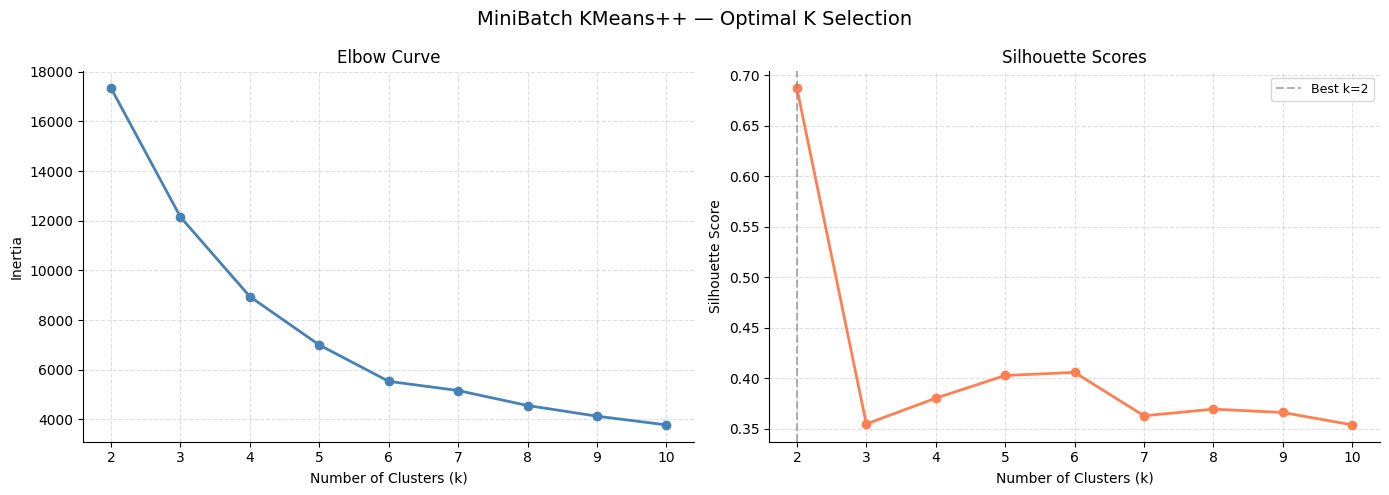


   k       Inertia    Silhouette
--------------------------------
   2      17337.79        0.6874 ◀ best
   3      12150.51        0.3546
   4       8946.94        0.3802
   5       6998.73        0.4027
   6       5535.54        0.4057
   7       5164.93        0.3627
   8       4562.18        0.3693
   9       4132.32        0.3660
  10       3781.77        0.3537

Suggested optimal k: 2


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# ── Features ──────────────────────────────────────────────────────────────────

features = ['tweet_count', 'likes_total', 'retweets_total']
X        = user_agg[features].fillna(0)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Elbow + Silhouette ────────────────────────────────────────────────────────

K          = range(2, 11)
inertias   = []
sil_scores = []
batch_size = min(1024, len(X_scaled))

for k in K:
    km = MiniBatchKMeans(
        n_clusters  = k,
        init        = 'k-means++',
        n_init      = 10,
        max_iter    = 300,
        batch_size  = batch_size,
        random_state= 42
    )
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

# ── Plot Elbow + Silhouette ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MiniBatch KMeans++ — Optimal K Selection", fontsize=14)

# Elbow
ax = axes[0]
ax.plot(K, inertias, marker='o', color='steelblue', linewidth=2)
ax.set_title("Elbow Curve", fontsize=12)
ax.set_xlabel("Number of Clusters (k)", fontsize=10)
ax.set_ylabel("Inertia", fontsize=10)
ax.grid(linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

# Silhouette
ax = axes[1]
best_k = list(K)[np.argmax(sil_scores)]
ax.plot(K, sil_scores, marker='o', color='coral', linewidth=2)
ax.axvline(best_k, linestyle='--', color='gray', alpha=0.6, label=f'Best k={best_k}')
ax.set_title("Silhouette Scores", fontsize=12)
ax.set_xlabel("Number of Clusters (k)", fontsize=10)
ax.set_ylabel("Silhouette Score", fontsize=10)
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
display(fig)
plt.close(fig)

# ── Print scores ──────────────────────────────────────────────────────────────

print(f"\n{'k':>4}  {'Inertia':>12}  {'Silhouette':>12}")
print("-" * 32)
for k, inertia, sil in zip(K, inertias, sil_scores):
    marker = " ◀ best" if k == best_k else ""
    print(f"{k:>4}  {inertia:>12.2f}  {sil:>12.4f}{marker}")

print(f"\nSuggested optimal k: {best_k}")

### Comments

**Statistical metrics suggest one answer, but business needs may differ!**

We select k = 4 to achieve a balance between statistical robustness and business interpretability, while also optimizing the trade-off between inertia and silhouette score.

### 🧬 4. Cluster Profiling — Indexed Means
After choosing the optimal k, label each author with their cluster assignment. For each cluster, compute the mean of each metric and express it as an index score relative to the overall mean:

A score of 100 means the cluster mean equals the overall mean
A score > 100 means the cluster is above average on that metric
A score < 100 means the cluster is below average on that metric

In [8]:
from sklearn.cluster import MiniBatchKMeans

# ── 0. Choose k ───────────────────────────────────────────────────────────────
chosen_k     = 4
feature_cols = ['tweet_count', 'likes_total', 'retweets_total']

# ── 1. Fit final MiniBatchKMeans with chosen k ────────────────────────────────
cluster_df            = user_agg.copy()
km_final              = MiniBatchKMeans(n_clusters=chosen_k, init='k-means++', n_init=10,
                                        max_iter=300, batch_size=min(1024, len(X_scaled)),
                                        random_state=42)
cluster_df['cluster'] = km_final.fit_predict(X_scaled)

print(f"Cluster counts:\n{cluster_df['cluster'].value_counts().sort_index()}\n")

# ── 2. Cluster means & overall means ─────────────────────────────────────────
cluster_means = cluster_df.groupby('cluster')[feature_cols].mean()
overall_means = cluster_df[feature_cols].mean()

# ── 3. Index scores (cluster mean / overall mean * 100) ──────────────────────
index_scores       = (cluster_means / overall_means * 100).round(1)
index_scores.index = [f"Cluster {i}" for i in index_scores.index]

print("Index Scores (100 = overall mean):")
display(index_scores)


Cluster counts:
cluster
0    2648
1    3433
2     469
3    2815
Name: count, dtype: int64

Index Scores (100 = overall mean):


,tweet_count,likes_total,retweets_total
Cluster 0,94.5,133.4,44.9
Cluster 1,94.5,38.1,89.0
Cluster 2,203.9,203.3,206.2
Cluster 3,94.5,126.9,147.5


### 🌡️ Cluster Index Score Heatmap
- Visualise indexed cluster means as a heatmap.
- Red → below average
- White → at the overall mean (score = 100)
- Green → above average

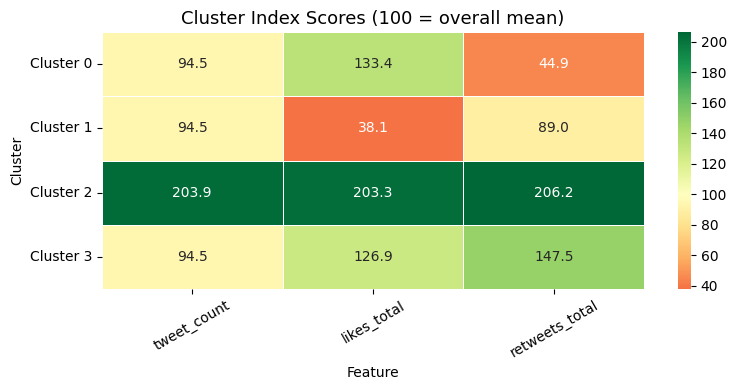

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(
    index_scores,
    annot      = True,
    fmt        = '.1f',
    cmap       = 'RdYlGn',
    center     = 100,
    linewidths = 0.5,
    linecolor  = 'white',
    ax         = ax
)

ax.set_title("Cluster Index Scores (100 = overall mean)", fontsize=13)
ax.set_xlabel("Feature", fontsize=10)
ax.set_ylabel("Cluster", fontsize=10)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
display(fig)
plt.close(fig)

## 👥 5. Cluster Profile Interpretation

| Cluster | Activity | Likes | Retweets | Profile |
|---------|----------|-------|----------|---------|
| 0 | Average | High | Low | Likeable Writers |
| 1 | Average | Low | Medium | Shareworthy |
| 2 | High | High | High | Power Users |
| 3 | Average | Medium | High | Retweet Magnets |

---

### Cluster 0 — Liked but not shared ("Likeable Writers")
Average activity (`94.5`), above-average likes (`133.4`) but very low retweets (`44.9`).
These users produce content people appreciate but don't feel compelled to share.
Good at generating **passive engagement**.

---

### Cluster 1 — Shareworthy but not Liked ("Informational Broadcasters")
Average activity (`94.5`), very low likes (`38.1`) but above-average retweets (`89.0`).
Content spreads but doesn't resonate emotionally.
Likely **informational or news-style tweets** that get passed on without a like.

---

### Cluster 2 — All-Round High Performers ("Power Users")
Well above average on everything — tweets (`203.9`), likes (`203.3`), retweets (`206.2`).
These are the **most active and most engaging users** on the platform.
Likely influencers or highly followed accounts.

---

### Cluster 3 — Retweet Magnets ("Viral Potential")
Average activity (`94.5`), above-average likes (`126.9`), and high retweets (`147.5`).
These users **punch above their weight** — despite not tweeting more than others, their content spreads significantly.
Strong candidates for **organic amplification**.